In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
train = pd.read_csv('./datathon-2026-round-1/sales.csv')
test  = pd.read_csv('./datathon-2026-round-1/sample_submission.csv')

train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

Train shape: (3833, 3)
Test shape : (548, 3)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [3]:
# ============================================================
# Feature Engineering từ Date (không dùng Revenue/COGS của test)
# ============================================================
def make_features(df):
    df = df.copy()
    df['year']       = df['Date'].dt.year
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun
    df['quarter']    = df['Date'].dt.quarter
    df['dayofyear']  = df['Date'].dt.dayofyear
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
    return df

train = make_features(train)
test  = make_features(test)

FEATURES = ['year', 'month', 'day', 'dayofweek', 'quarter',
            'dayofyear', 'weekofyear', 'is_weekend',
            'is_month_start', 'is_month_end']

print('Features:', FEATURES)

Features: ['year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end']


In [4]:
# ============================================================
# Time-Series Split — KHÔNG dùng random split cho time series!
# Dùng 2022 làm validation set
# ============================================================
SPLIT_DATE = '2022-01-01'

tr = train[train['Date'] < SPLIT_DATE]
val = train[train['Date'] >= SPLIT_DATE]

X_train = tr[FEATURES]
y_rev_train  = tr['Revenue']
y_cogs_train = tr['COGS']

X_val = val[FEATURES]
y_rev_val  = val['Revenue']
y_cogs_val = val['COGS']

X_test = test[FEATURES]

print(f'Train: {len(X_train)} rows  |  Val: {len(X_val)} rows  |  Test: {len(X_test)} rows')

Train: 3468 rows  |  Val: 365 rows  |  Test: 548 rows


## XGBoost

In [5]:
# ============================================================
# XGBoost — predict Revenue
# ============================================================
xgb_rev = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)
xgb_rev.fit(
    X_train, y_rev_train,
    eval_set=[(X_train, y_rev_train), (X_val, y_rev_val)],
    verbose=50
)

[0]	validation_0-rmse:2658651.47915	validation_1-rmse:2038784.35222
[50]	validation_0-rmse:1888246.45647	validation_1-rmse:1385585.91288
[100]	validation_0-rmse:1424780.23479	validation_1-rmse:1040061.65147
[150]	validation_0-rmse:1154361.93160	validation_1-rmse:893933.26969
[200]	validation_0-rmse:990353.34203	validation_1-rmse:845984.85709
[250]	validation_0-rmse:881645.93675	validation_1-rmse:841664.05521
[300]	validation_0-rmse:809491.75424	validation_1-rmse:850940.28446
[350]	validation_0-rmse:756220.63053	validation_1-rmse:863160.87116
[400]	validation_0-rmse:711370.67311	validation_1-rmse:874615.28037
[450]	validation_0-rmse:672331.38533	validation_1-rmse:885445.33633
[499]	validation_0-rmse:638686.99431	validation_1-rmse:895196.76507


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
# ============================================================
# XGBoost — predict COGS
# ============================================================
xgb_cogs = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)
xgb_cogs.fit(
    X_train, y_cogs_train,
    eval_set=[(X_train, y_cogs_train), (X_val, y_cogs_val)],
    verbose=50
)

xgb_val_rev_pred  = xgb_rev.predict(X_val)
xgb_val_cogs_pred = xgb_cogs.predict(X_val)

print('--- XGBoost Revenue ---')
print(f'  MAE : {mean_absolute_error(y_rev_val, xgb_val_rev_pred):,.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_rev_val, xgb_val_rev_pred)):,.2f}')
print(f'  R²  : {r2_score(y_rev_val, xgb_val_rev_pred):.4f}')
print('--- XGBoost COGS ---')
print(f'  MAE : {mean_absolute_error(y_cogs_val, xgb_val_cogs_pred):,.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_cogs_val, xgb_val_cogs_pred)):,.2f}')
print(f'  R²  : {r2_score(y_cogs_val, xgb_val_cogs_pred):.4f}')

[0]	validation_0-rmse:2246336.46171	validation_1-rmse:1749982.80638
[50]	validation_0-rmse:1591722.32418	validation_1-rmse:1207968.82942
[100]	validation_0-rmse:1193164.88474	validation_1-rmse:921299.04095
[150]	validation_0-rmse:960396.19939	validation_1-rmse:788247.92049
[200]	validation_0-rmse:820035.81404	validation_1-rmse:737056.83884
[250]	validation_0-rmse:728233.57222	validation_1-rmse:723121.70511
[300]	validation_0-rmse:668039.34093	validation_1-rmse:719918.25906
[350]	validation_0-rmse:620221.22943	validation_1-rmse:723605.63886
[400]	validation_0-rmse:581890.34670	validation_1-rmse:729206.60989
[450]	validation_0-rmse:551168.93577	validation_1-rmse:733709.76893
[499]	validation_0-rmse:524778.09109	validation_1-rmse:737153.66071
--- XGBoost Revenue ---
  MAE : 645,040.08
  RMSE: 895,196.76
  R²  : 0.7140
--- XGBoost COGS ---
  MAE : 545,618.93
  RMSE: 737,153.67
  R²  : 0.7446


## Random Forest

In [7]:
# ============================================================
# Random Forest — predict Revenue
# ============================================================
rf_rev = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=4,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_rev.fit(X_train, y_rev_train)
print('Random Forest Revenue training completed!')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s


Random Forest Revenue training completed!


[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished


In [8]:
# ============================================================
# Random Forest — predict COGS
# ============================================================
rf_cogs = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=4,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_cogs.fit(X_train, y_cogs_train)
print('Random Forest COGS training completed!')

rf_val_rev_pred  = rf_rev.predict(X_val)
rf_val_cogs_pred = rf_cogs.predict(X_val)

print('--- Random Forest Revenue ---')
print(f'  MAE : {mean_absolute_error(y_rev_val, rf_val_rev_pred):,.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_rev_val, rf_val_rev_pred)):,.2f}')
print(f'  R²  : {r2_score(y_rev_val, rf_val_rev_pred):.4f}')
print('--- Random Forest COGS ---')
print(f'  MAE : {mean_absolute_error(y_cogs_val, rf_val_cogs_pred):,.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_cogs_val, rf_val_cogs_pred)):,.2f}')
print(f'  R²  : {r2_score(y_cogs_val, rf_val_cogs_pred):.4f}')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s


Random Forest COGS training completed!
--- Random Forest Revenue ---
  MAE : 637,330.02
  RMSE: 867,005.21
  R²  : 0.7317
--- Random Forest COGS ---
  MAE : 558,450.65
  RMSE: 758,972.78
  R²  : 0.7292


[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished


## LightGBM

In [9]:
# ============================================================
# LightGBM — predict Revenue
# ============================================================
import lightgbm as lgb

lgb_rev = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_rev.fit(
    X_train, y_rev_train,
    eval_set=[(X_val, y_rev_val)]
)

# LightGBM — predict COGS
lgb_cogs = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_cogs.fit(
    X_train, y_cogs_train,
    eval_set=[(X_val, y_cogs_val)]
)

lgb_val_rev_pred  = lgb_rev.predict(X_val)
lgb_val_cogs_pred = lgb_cogs.predict(X_val)

print("--- LightGBM Revenue ---")
print(f"  MAE : {mean_absolute_error(y_rev_val, lgb_val_rev_pred):,.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_rev_val, lgb_val_rev_pred)):,.2f}")
print(f"  R²  : {r2_score(y_rev_val, lgb_val_rev_pred):.4f}")
print("--- LightGBM COGS ---")
print(f"  MAE : {mean_absolute_error(y_cogs_val, lgb_val_cogs_pred):,.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_cogs_val, lgb_val_cogs_pred)):,.2f}")
print(f"  R²  : {r2_score(y_cogs_val, lgb_val_cogs_pred):.4f}")


--- LightGBM Revenue ---
  MAE : 632,119.37
  RMSE: 876,409.28
  R²  : 0.7258
--- LightGBM COGS ---
  MAE : 539,188.42
  RMSE: 737,178.94
  R²  : 0.7446


## Prophet

In [10]:
# ============================================================
# Prophet — predict Revenue
# Prophet yêu cầu cột ds (date) và y (target)
# ============================================================
from prophet import Prophet

def train_prophet(train_df, target_col):
    df_p = train_df[["Date", target_col]].rename(columns={"Date": "ds", target_col: "y"})
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",  # phù hợp với doanh thu có trend tăng
        changepoint_prior_scale=0.05
    )
    m.fit(df_p)
    return m

prophet_rev  = train_prophet(tr, "Revenue")
prophet_cogs = train_prophet(tr, "COGS")

# Predict trên val
val_future = val[["Date"]].rename(columns={"Date": "ds"})
prophet_val_rev_pred  = prophet_rev.predict(val_future)["yhat"].values
prophet_val_cogs_pred = prophet_cogs.predict(val_future)["yhat"].values

print("--- Prophet Revenue ---")
print(f"  MAE : {mean_absolute_error(y_rev_val, prophet_val_rev_pred):,.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_rev_val, prophet_val_rev_pred)):,.2f}")
print(f"  R²  : {r2_score(y_rev_val, prophet_val_rev_pred):.4f}")
print("--- Prophet COGS ---")
print(f"  MAE : {mean_absolute_error(y_cogs_val, prophet_val_cogs_pred):,.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_cogs_val, prophet_val_cogs_pred)):,.2f}")
print(f"  R²  : {r2_score(y_cogs_val, prophet_val_cogs_pred):.4f}")


21:39:19 - cmdstanpy - INFO - Chain [1] start processing
21:39:19 - cmdstanpy - INFO - Chain [1] done processing
21:39:19 - cmdstanpy - INFO - Chain [1] start processing
21:39:19 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Revenue ---
  MAE : 903,953.21
  RMSE: 1,335,262.33
  R²  : 0.3636
--- Prophet COGS ---
  MAE : 804,383.23
  RMSE: 1,166,558.52
  R²  : 0.3603


## Ensemble

## Model Selection — Try All Combinations

In [11]:
# ============================================================
# Predict trên test set cho tất cả models
# ============================================================
xgb_test_rev_pred  = xgb_rev.predict(X_test)
xgb_test_cogs_pred = xgb_cogs.predict(X_test)
rf_test_rev_pred   = rf_rev.predict(X_test)
rf_test_cogs_pred  = rf_cogs.predict(X_test)
lgb_test_rev_pred  = lgb_rev.predict(X_test)
lgb_test_cogs_pred = lgb_cogs.predict(X_test)
test_future = test[["Date"]].rename(columns={"Date": "ds"})
prophet_test_rev_pred  = prophet_rev.predict(test_future)["yhat"].values
prophet_test_cogs_pred = prophet_cogs.predict(test_future)["yhat"].values
print("✅ All test predictions done!")


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished


✅ All test predictions done!


In [12]:
# ============================================================
# Thử tất cả combinations, so sánh trên validation
# rồi AUTO-SELECT combination tốt nhất để submit
# ============================================================
from itertools import combinations

# Tập hợp tất cả predictions trên val và test
all_preds_val = {
    "XGBoost"      : (xgb_val_rev_pred,  xgb_val_cogs_pred),
    "RandomForest" : (rf_val_rev_pred,   rf_val_cogs_pred),
    "LightGBM"     : (lgb_val_rev_pred,  lgb_val_cogs_pred),
    "Prophet"      : (prophet_val_rev_pred, prophet_val_cogs_pred),
}
all_preds_test = {
    "XGBoost"      : (xgb_test_rev_pred,  xgb_test_cogs_pred),
    "RandomForest" : (rf_test_rev_pred,   rf_test_cogs_pred),
    "LightGBM"     : (lgb_test_rev_pred,  lgb_test_cogs_pred),
    "Prophet"      : (prophet_test_rev_pred, prophet_test_cogs_pred),
}

model_names = list(all_preds_val.keys())
results = []

# Thử từng model đứng riêng + mọi combination 2, 3, 4 models
for r in range(1, len(model_names) + 1):
    for combo in combinations(model_names, r):
        # Equal weight cho mỗi model trong combo
        w = 1.0 / len(combo)
        rev_pred  = sum(w * all_preds_val[m][0] for m in combo)
        cogs_pred = sum(w * all_preds_val[m][1] for m in combo)

        mae  = mean_absolute_error(y_rev_val, rev_pred)
        rmse = np.sqrt(mean_squared_error(y_rev_val, rev_pred))
        r2   = r2_score(y_rev_val, rev_pred)

        results.append({
            "Combination" : " + ".join(combo),
            "N_models"    : len(combo),
            "MAE"         : mae,
            "RMSE"        : rmse,
            "R2"          : r2,
            "combo_keys"  : combo
        })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df[["Combination", "N_models", "MAE", "RMSE", "R2"]].to_string(index=False))

# Auto-select best combination (lowest RMSE)
best = results_df.iloc[0]
best_combo = best["combo_keys"]
print(f"✅ Best combination: {best['Combination']}")
print(f"   MAE={best['MAE']:,.2f} | RMSE={best['RMSE']:,.2f} | R²={best['R2']:.4f}")


                                Combination  N_models           MAE         RMSE       R2
                    RandomForest + LightGBM         2 621649.898669 8.569605e+05 0.737874
                     XGBoost + RandomForest         2 630268.306884 8.618159e+05 0.734896
          XGBoost + RandomForest + LightGBM         3 627352.764290 8.622619e+05 0.734621
                               RandomForest         1 637330.022657 8.670052e+05 0.731694
                                   LightGBM         1 632119.372645 8.764093e+05 0.725842
                         XGBoost + LightGBM         2 635636.090056 8.809365e+05 0.723002
                                    XGBoost         1 645040.082479 8.951968e+05 0.713961
XGBoost + RandomForest + LightGBM + Prophet         4 650049.690486 9.109024e+05 0.703837
           XGBoost + RandomForest + Prophet         3 670427.714523 9.411266e+05 0.683857
               XGBoost + LightGBM + Prophet         3 667561.707739 9.423539e+05 0.683032
          

## Export Best Submission

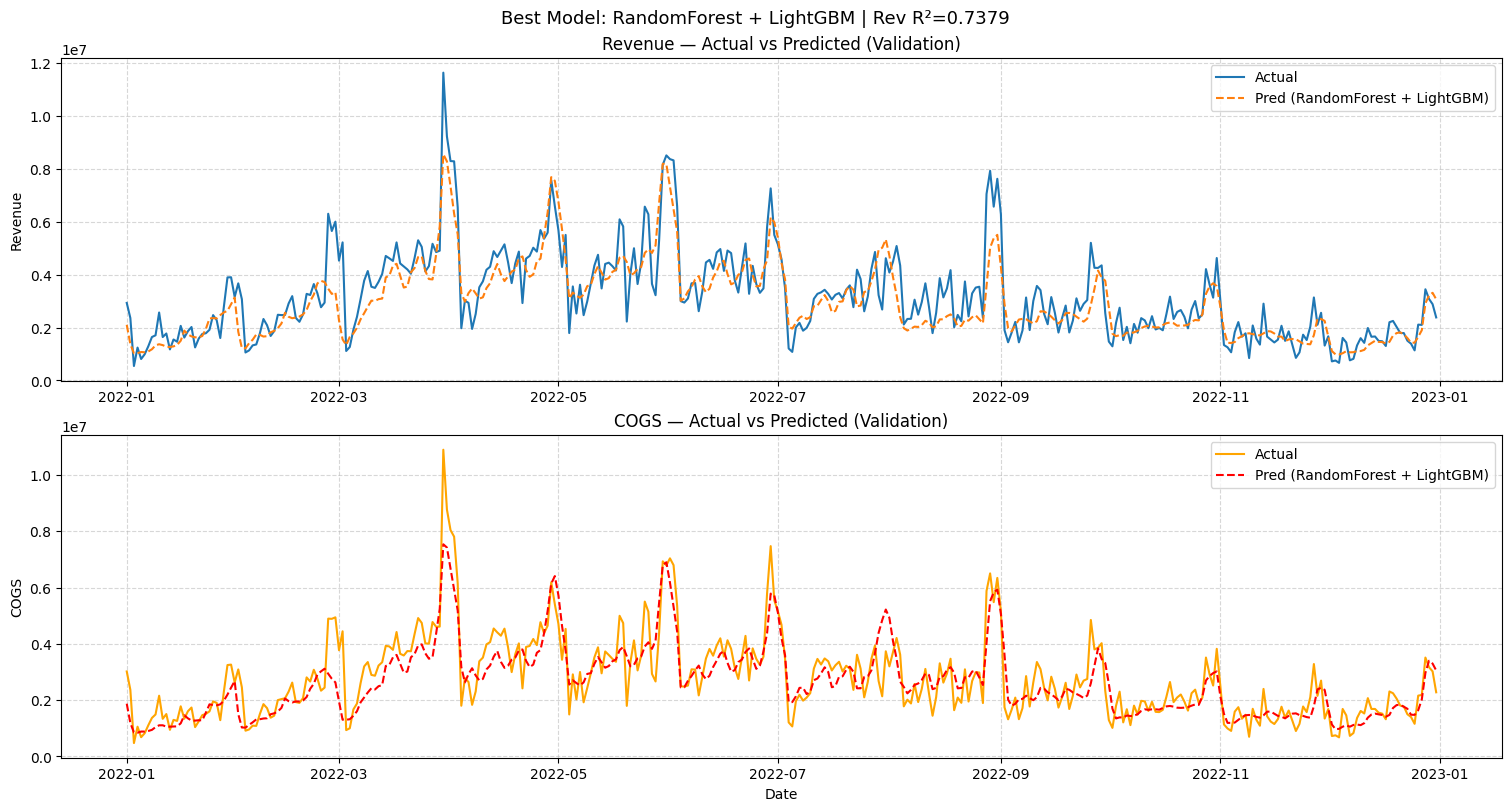

In [13]:
# ============================================================
# Plot actual vs predicted — Revenue & COGS trên validation
# (dùng best combination đã chọn ở trên)
# ============================================================
w = 1.0 / len(best_combo)
best_val_rev_pred  = sum(w * all_preds_val[m][0] for m in best_combo)
best_val_cogs_pred = sum(w * all_preds_val[m][1] for m in best_combo)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)

# Revenue
axes[0].plot(val['Date'].values, y_rev_val.values, label='Actual', linewidth=1.5)
axes[0].plot(val['Date'].values, best_val_rev_pred, label=f"Pred ({best['Combination']})",
             linewidth=1.5, linestyle='--')
axes[0].set_title('Revenue — Actual vs Predicted (Validation)')
axes[0].set_ylabel('Revenue')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# COGS
axes[1].plot(val['Date'].values, y_cogs_val.values, label='Actual', linewidth=1.5, color='orange')
axes[1].plot(val['Date'].values, best_val_cogs_pred, label=f"Pred ({best['Combination']})",
             linewidth=1.5, linestyle='--', color='red')
axes[1].set_title('COGS — Actual vs Predicted (Validation)')
axes[1].set_ylabel('COGS')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f"Best Model: {best['Combination']} | Rev R²={best['R2']:.4f}", fontsize=13)
plt.show()

In [14]:
# ============================================================
# Xuất submission từ best combination
# ============================================================
w = 1.0 / len(best_combo)
final_rev_pred  = sum(w * all_preds_test[m][0] for m in best_combo)
final_cogs_pred = sum(w * all_preds_test[m][1] for m in best_combo)

submission = pd.DataFrame({
    "Date"   : test["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": final_rev_pred,
    "COGS"   : final_cogs_pred
})

submission.to_csv("./datathon-2026-round-1/submissionv3.csv", index=False)
print(f"✅ Saved submission.csv using: {best['Combination']}")
print(f"   Shape: {submission.shape}")
submission.head()


✅ Saved submission.csv using: RandomForest + LightGBM
   Shape: (548, 3)


,Date,Revenue,COGS
0,2023-01-01,2.149576e+06,1.889803e+06
1,2023-01-02,1.083928e+06,9.370882e+05
2,2023-01-03,9.567733e+05,8.285947e+05
3,2023-01-04,9.899424e+05,8.012081e+05
4,2023-01-05,1.037376e+06,8.788527e+05


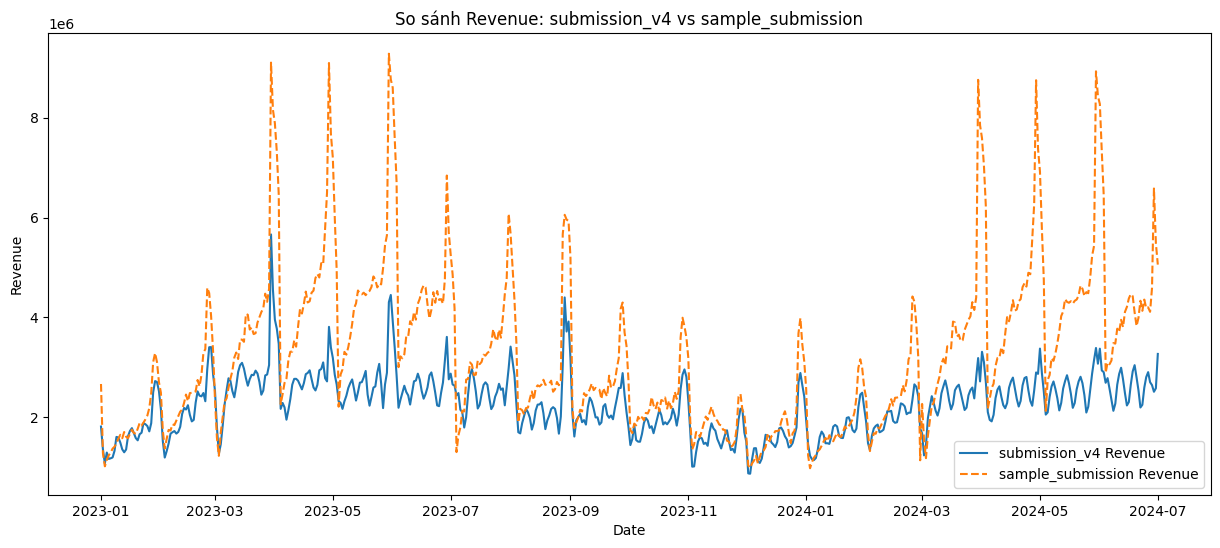

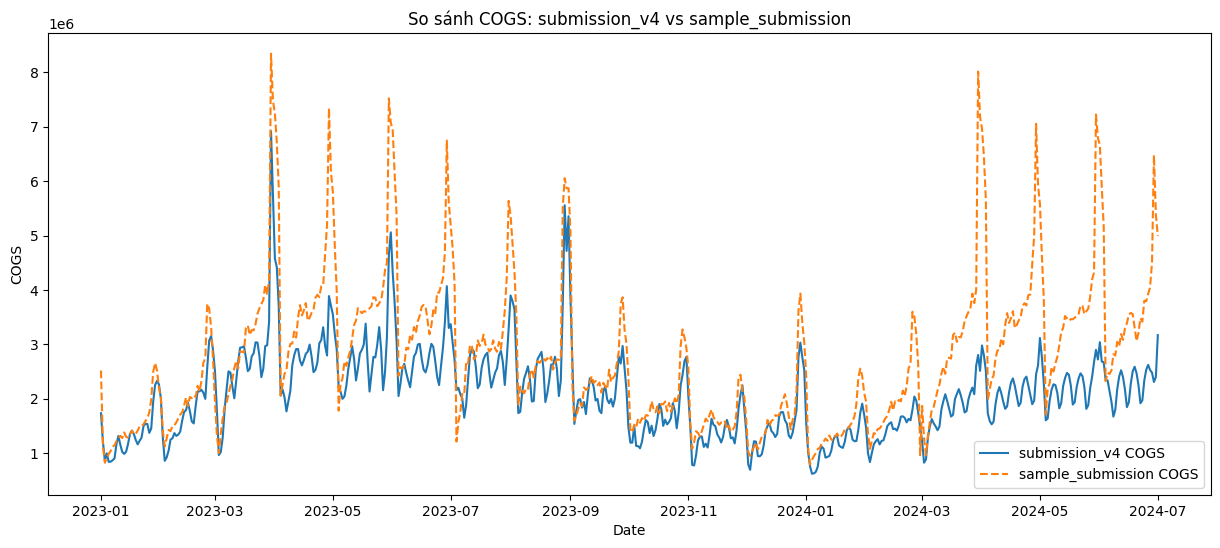

In [18]:
# Đọc file submission_v4 và sample_submission
submission_v4 = pd.read_csv('./datathon-2026-round-1/submissionv7.csv')
sample_submission = pd.read_csv('./datathon-2026-round-1/sample_submission.csv')

# Đảm bảo cột Date là kiểu datetime
submission_v4['Date'] = pd.to_datetime(submission_v4['Date'])
sample_submission['Date'] = pd.to_datetime(sample_submission['Date'])

# Vẽ biểu đồ so sánh Revenue
plt.figure(figsize=(15, 6))
plt.plot(submission_v4['Date'], submission_v4['Revenue'], label='submission_v4 Revenue')
plt.plot(sample_submission['Date'], sample_submission['Revenue'], label='sample_submission Revenue', linestyle='--')
plt.title('So sánh Revenue: submission_v4 vs sample_submission')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

# Vẽ biểu đồ so sánh COGS
plt.figure(figsize=(15, 6))
plt.plot(submission_v4['Date'], submission_v4['COGS'], label='submission_v4 COGS')
plt.plot(sample_submission['Date'], sample_submission['COGS'], label='sample_submission COGS', linestyle='--')
plt.title('So sánh COGS: submission_v4 vs sample_submission')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.show()